<a href="https://colab.research.google.com/github/sruzzante/Caravan-CMIP6/blob/main/Caravan_CMIP6_Colab_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Caravan-CMIP6 is an extension to the Caravan dataset presented by [Kratzert et al in 2022](https://www.nature.com/articles/s41597-023-01975-w). It is intended to make it easier for the large-sample hydrologic community to project streamflow under climate change.

Caravan-CMIP6 provides CMIP6 climate model projections for catchments within ten large-sample hydrometeorologic datasets, including:
- 10 large-sample hydrology datasets: Caravan, CAMELS, CAMELS-AUS-v2, CAMELS-BR, CAMELS-CH CAMELS-CL, CAMELS-COL, CAMELS-DE, CAMELS-GB-v2, and CAMELS-IND
- 12 climate models
- both raw and bias-corrected data
- the historical experiment (1850-2014) and three scenarios (ssp 126, ssp 245, and ssp 585) from 2015-2100
- many meteorological variables, including precipitation, temperature, evapotranspiration, humidity, radiation, pressure, and wind speed.

A subset of the full dataset - the bias-corrected projections for Caravan, including commmunity extensions - is available on Google Cloud Platform and this notebook demonstrates how to access these data.

## Purpose of this notebook

This notebook exemplifies how to read the Caravan-CMIP6 data from the GCP bucket. This allows immediate access to any subset of the data without downloading the entire dataset (1.8TB), thanks to the zarr format in which the data is stored.

## Related resources
The full dataset is available at https://doi.org/10.20383/103.01644.

A preprint with technical details is available at https://doi.org/10.5194/essd-2026-350



# Run on Colab

This notebook can be executed on Colab by clicking on the button at the top. This is our recommended way to dive into the CMIP6 extension so that you don't need to worry about setting up a local environment for first data inspections.



# Acknowledgements
This script was adapted from Frederik Kratzert's [example script](https://github.com/kratzert/Caravan/blob/main/examples/Caravan_MultiMet_Extending_Caravan_with_Multiple_Weather_Nowcasts_and_Forecasts.ipynb) for Caravan-Multimet

# Setup

In [ ]:
# Execute this block when running on Colab to install the missing packages.
!pip install zarr xarray cftime nc-time-axis

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import zarr
import gcsfs
import cftime
import nc_time_axis
import pandas as pd

In [ ]:
# Open the dataset with zarr to inspect the contents
fs = gcsfs.GCSFileSystem(token="anon")
mapper = fs.get_mapper("caravan-cmip6/Caravan_CMIP6_QDM.zarr")

z = zarr.open(mapper, mode="r")

In [ ]:
# See the first-level contents of the root directory
# Level 0 = source_id (the 12 CMIP6 models)
z.tree(level=0)

/
├── ACCESS-ESM1-5
├── CNRM-CM6-1-HR
├── CanESM5
├── EC-Earth3
├── GFDL-CM4
├── INM-CM5-0
├── IPSL-CM6A-LR
├── MIROC6
├── MPI-ESM1-2-HR
├── MRI-ESM2-0
├── TaiESM1
└── UKESM1-0-LL

In [ ]:
# Open a source_id group and see the contents
z1 = z["UKESM1-0-LL"]
z1.tree(level=0)

/UKESM1-0-LL
├── historical
├── ssp126
├── ssp245
└── ssp585

In [ ]:
# Open an experiment_id group and see the contents
z2 = z1["ssp245"]
z2.tree(level=0)

/UKESM1-0-LL/ssp245
├── r1i1p1f2
├── r2i1p1f2
├── r3i1p1f2
├── r4i1p1f2
└── r8i1p1f2

In [ ]:
# Open a variant_id group and see the contents
z3 = z2["r1i1p1f2"]
z3.tree(level=0)

/UKESM1-0-LL/ssp245/r1i1p1f2
├── dewpoint_temperature_2m_mean (30960, 24870) int16
├── id (24870,) StringDType()
├── potential_evaporation_sum_FAO_PENMAN_MONTEITH (30960, 24870) int16
├── surface_net_solar_radiation_mean (30960, 24870) int16
├── surface_net_thermal_radiation_mean (30960, 24870) int16
├── surface_pressure_mean (30960, 24870) int16
├── temperature_2m_max (30960, 24870) int16
├── temperature_2m_mean (30960, 24870) int16
├── temperature_2m_min (30960, 24870) int16
├── time (30960,) float64
├── total_precipitation_sum (30960, 24870) int16
└── wind_10m_mean (30960, 24870) int16

In [ ]:
# Now use xarray to access the data
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
def open_zarr(path):
  return xr.open_dataset(
      filename_or_obj=path,
      engine = "zarr",
      chunks={},
      storage_options=dict(token='anon'),
      consolidated=False,
      decode_times=time_coder
  )

In [ ]:
# Open one ensemble member
source_id = "UKESM1-0-LL"
experiment_id = "ssp245"
variant_label = "r1i1p1f2"


ds = open_zarr(
    "gs://caravan-cmip6/Caravan_CMIP6_QDM.zarr/%s/%s/%s"%(source_id, experiment_id, variant_label)
   )


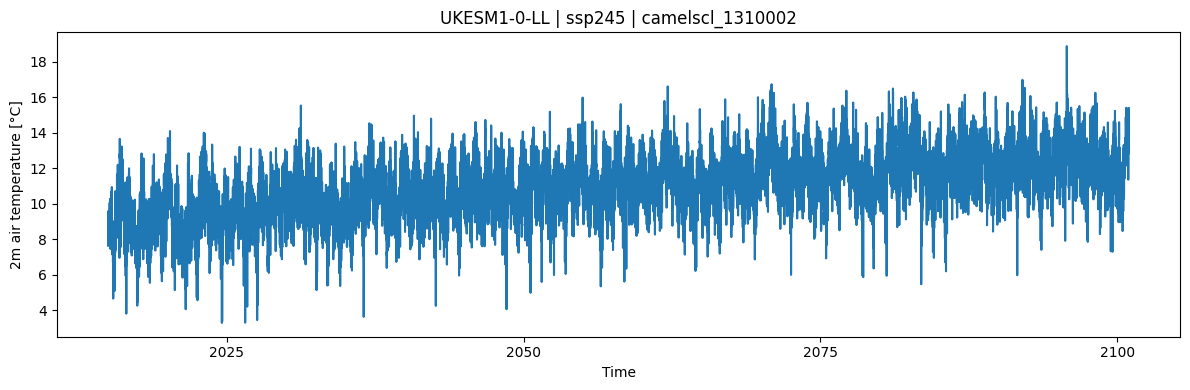

In [ ]:
# Get and plot 2m mean temperature for camelscl_1310002

variable_id = "temperature_2m_mean"
gauge_id = "camelscl_1310002"



t2m = ds[variable_id].sel(id=gauge_id)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t2m.indexes["time"], t2m.values)
ax.set_xlabel("Time")
ax.set_ylabel(t2m.attrs.get("units", "temperature_2m_mean"))
ax.set_title(f"{source_id} | {experiment_id} | {gauge_id}")
plt.tight_layout()
plt.show()

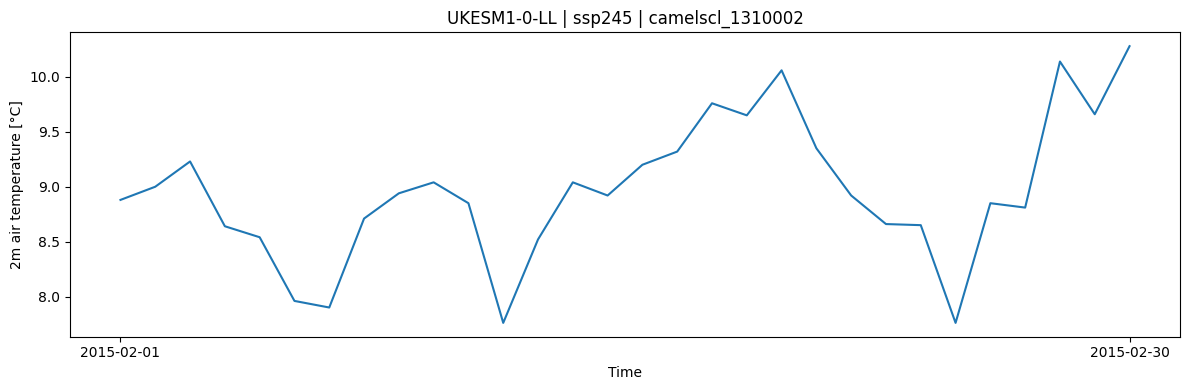

In [ ]:
# Confirm that the CF calendar is being properly interpreted
# February 30 is a valid date in the 360_day calendar used by UKESM1-0-LL

time_period = slice("2015-02-01", "2015-02-30")
t2m_x = ds[variable_id].sel(id=gauge_id,time = time_period)


fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t2m_x.indexes["time"], t2m_x.values)
ax.set_xlabel("Time")
ax.set_xticks([
    cftime.Datetime360Day(2015, 2, 1),
    cftime.Datetime360Day(2015, 2, 30)
])
ax.set_ylabel(t2m_x.attrs.get("units", "temperature_2m_mean"))
ax.set_title(f"{source_id} | {experiment_id} | {gauge_id}")
plt.tight_layout()
plt.show()

In [ ]:
# Now get all ensemble members for a single gauge
# First, make a dataframe of all the ensemble members available for an experiment (ssp245)


records = []
for source_id in z.keys():
    # We'll only use the ssp245 experiment
    exps = list(z[source_id].keys())
    exps = [e for e in z[source_id].keys() if e in {"ssp245"}]

    for experiment_id in exps:
        for variant_label in z[source_id][experiment_id].keys():
            records.append({
                "source_id": source_id,
                "experiment_id": experiment_id,
                "variant_label": variant_label
            })

df = pd.DataFrame(records)
print(df)

        source_id experiment_id variant_label
0   ACCESS-ESM1-5        ssp245     r10i1p1f1
1   ACCESS-ESM1-5        ssp245      r1i1p1f1
2   ACCESS-ESM1-5        ssp245      r2i1p1f1
3   ACCESS-ESM1-5        ssp245      r3i1p1f1
4   ACCESS-ESM1-5        ssp245      r4i1p1f1
5   ACCESS-ESM1-5        ssp245      r5i1p1f1
6   ACCESS-ESM1-5        ssp245      r6i1p1f1
7   ACCESS-ESM1-5        ssp245      r7i1p1f1
8   ACCESS-ESM1-5        ssp245      r8i1p1f1
9   ACCESS-ESM1-5        ssp245      r9i1p1f1
10        CanESM5        ssp245     r10i1p1f1
11        CanESM5        ssp245      r1i1p1f1
12        CanESM5        ssp245      r1i1p2f1
13        CanESM5        ssp245      r6i1p2f1
14        CanESM5        ssp245      r7i1p1f1
15        CanESM5        ssp245      r7i1p2f1
16        CanESM5        ssp245      r8i1p1f1
17        CanESM5        ssp245      r8i1p2f1
18        CanESM5        ssp245      r9i1p1f1
19        CanESM5        ssp245      r9i1p2f1
20      EC-Earth3        ssp245   

In [ ]:
# Now read all the historical and ssp245 temperature data for one gauge,
# and summarize to annual means
# Takes ~10 minutes
datasets = {}
for _, row in df.iterrows():
  # historical
    path = "gs://caravan-cmip6/Caravan_CMIP6_QDM.zarr/%s/%s/%s" % (
        row.source_id, "historical", row.variant_label
    )
    ds = open_zarr(path)
    da = ds["temperature_2m_mean"].sel(id=gauge_id)
    da_annual_hist = da.resample(time="YS").mean()

    # ssp245
    path = "gs://caravan-cmip6/Caravan_CMIP6_QDM.zarr/%s/%s/%s" % (
        row.source_id, row.experiment_id, row.variant_label
    )
    ds = open_zarr(path)
    da = ds["temperature_2m_mean"].sel(id=gauge_id)
    da_annual_proj = da.resample(time="YS").mean()

    # concatenate the historical and projected data

    da_annual = xr.concat(objs = (da_annual_hist,da_annual_proj),
                           dim = "time")

    datasets[(row.source_id, row.experiment_id, row.variant_label)] = da_annual



In [ ]:
# Also get ERA5_LAND data from the multimet dataset, for comparison

# Note that the data were bias-corrected to the original Caravan-CMIP6 data, not
# the multimet extension. There are some slight differences in average values
# between the original dataset and the multimet extension due to differences in
# the 'cookie-cutting' algorithms used to extract basin-average values from the
# rasters.
ds_ERA5_multimet = xr.open_dataset(
      filename_or_obj="gs://caravan-multimet/v1.1/ERA5_LAND/timeseries.zarr/",
      engine = "zarr",
      chunks={},
      storage_options=dict(token='anon'),
  )

t2m_ERA5_LAND = (
    ds_ERA5_multimet["era5land_temperature_2m"]
    .sel(basin = gauge_id)
    .compute().resample(date="YS")
    .mean()
    .rolling(date=10, center=False)
    .mean()
)


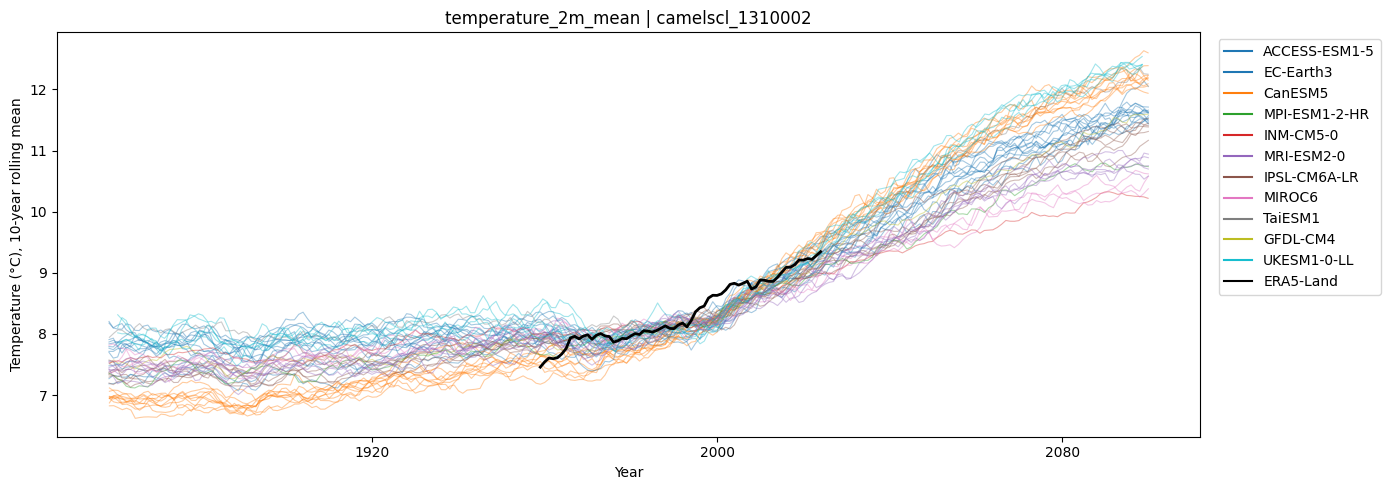

In [ ]:

fig, ax = plt.subplots(figsize=(14, 5))

source_ids = list({k[0] for k in datasets.keys()})
colors = {s: cm.tab10(i / len(source_ids)) for i, s in enumerate(source_ids)}

for (source_id, experiment_id, variant_label), da in datasets.items():
    da_smooth = da.compute().rolling(time=10, center=False).mean()
    ax.plot(da_smooth.time.values, da_smooth.values,
            color=colors[source_id], linewidth=0.8, alpha=0.4)

# Add one legend entry per source_id
for source_id, color in colors.items():
    ax.plot([], [], color=color, label=source_id)



ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C), 10-year rolling mean")
ax.set_title(f"temperature_2m_mean | {gauge_id}")

# Add ERA5_Land data to plot

# Convert ERA5_Land dates to cftime
cftime_era5_times = [cftime.DatetimeGregorian(t.year, t.month, t.day) for t in t2m_ERA5_LAND.indexes["date"]]
ax.plot(cftime_era5_times, t2m_ERA5_LAND,
          color="black", linewidth=2, alpha=1)
ax.plot([], [], color="black", label="ERA5-Land")

ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()